<a href="https://colab.research.google.com/github/Innovatewithapple/SKLearnRegressionProblems/blob/main/Regression_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import os
from google.colab import files,userdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_validate,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [16]:
!kaggle datasets download -d mosapabdelghany/medical-insurance-cost-dataset
!unzip -q /content/medical-insurance-cost-dataset.zip -d /content/

Dataset URL: https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset
License(s): CC0-1.0
medical-insurance-cost-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/insurance.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [17]:
df = pd.read_csv('/content/insurance.csv')
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
174,24,female,33.345,0,no,northwest,2855.43755
916,43,female,26.885,0,yes,northwest,21774.32215
33,63,male,28.310,0,no,northwest,13770.09790
1149,42,male,34.100,0,no,southwest,5979.73100
206,59,male,26.400,0,no,southeast,11743.29900


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [19]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Text(0.5, 1.0, 'Age vs Insurance Charges')

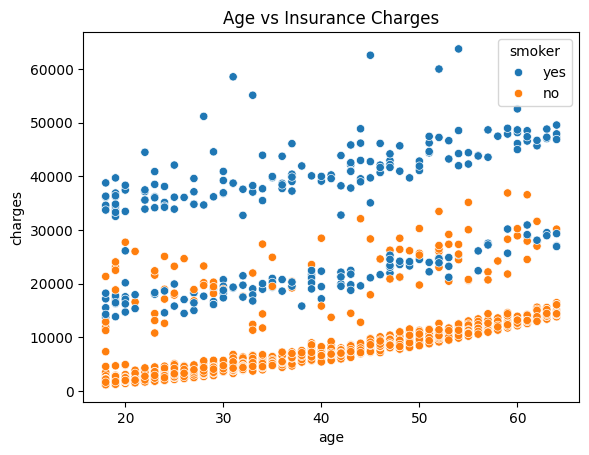

In [20]:
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Insurance Charges")

In [21]:
x = df.drop(columns='charges')
y = df['charges']

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [23]:
num_cols = x.select_dtypes(include=['int64','float64']).columns
cat_cols = x.select_dtypes(include=['object']).columns

In [24]:
preprocess = ColumnTransformer([
    ('nums',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(),cat_cols)
])

Linear-Regression

In [25]:
linear_pipeline = Pipeline([
    ('preprocessor',preprocess),
    ('model',LinearRegression())
])

In [26]:
linear_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', LinearRegression())])

In [27]:
linear_crossVal = cross_validate(linear_pipeline,x_train,y_train,cv=5,scoring='r2')
linear_crossVal

{'fit_time': array([0.01768017, 0.01316476, 0.01363277, 0.01279712, 0.00983906]),
 'score_time': array([0.01044965, 0.00902009, 0.00803065, 0.00635076, 0.00637412]),
 'test_score': array([0.76276797, 0.80048429, 0.63171109, 0.68603936, 0.75806544])}

Lasso(L1) & Ridge(L2)

In [28]:
Ridge_pipeline = Pipeline([
    ('preprocessor',preprocess),
    ('model',Ridge())
])

Lasso_pipeline = Pipeline([
    ('preprocessor',preprocess),
    ('model',Lasso())
])

In [29]:
Ridge_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', Ridge())])

In [30]:
Lasso_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', Lasso())])

In [31]:
Ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]}
Lasso_param_grid = {'model__alpha': [0.001,0.01,0.1, 1.0, 10.0]}

In [32]:
Ridge_gridcv = GridSearchCV(Ridge_pipeline,param_grid=Ridge_param_grid,cv=5,scoring='r2')
Ridge_gridcv.fit(x_train,y_train)
print(f'Best_Param: {Ridge_gridcv.best_params_}')
print(f'Best_R2_Score: {Ridge_gridcv.best_score_}')

Best_Param: {'model__alpha': 1.0}
Best_R2_Score: 0.7278896681043466


In [35]:
Lasso_gridcv = GridSearchCV(Lasso_pipeline,param_grid=Lasso_param_grid,cv=5,scoring='r2')
Lasso_gridcv.fit(x_train,y_train)
print(f'Best_Param: {Lasso_gridcv.best_params_}')
print(f'Best_R2_Score: {Lasso_gridcv.best_score_}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.107e+08, tolerance: 1.088e+07
  model = cd_fast.enet_coordinate_descent(


Best_Param: {'model__alpha': 10.0}
Best_R2_Score: 0.7280207099432561


SVR

In [36]:
svr_pipeline = Pipeline([
    ('preprocessor',preprocess),
    ('model',SVR(kernel='rbf'))
])
svr_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', SVR())])

In [37]:
svr_crossVal = cross_validate(svr_pipeline,x_train,y_train,cv=5,scoring='r2')
svr_crossVal

{'fit_time': array([0.11615586, 0.13559031, 0.07112813, 0.08825088, 0.07266665]),
 'score_time': array([0.0259974 , 0.08755016, 0.02593088, 0.06226397, 0.0243938 ]),
 'test_score': array([-0.10961192, -0.14663747, -0.12720023, -0.09102714, -0.04413055])}

In [38]:
svr_param_grid = {
    # We move from tiny C to massive C
    'model__C': [1, 100, 1000, 10000, 50000],
    'model__epsilon': [0.1, 1, 10, 100, 1000],
    'model__kernel': ['rbf']
}
svr_gridSearchcv = GridSearchCV(svr_pipeline,param_grid=svr_param_grid,cv=5,n_jobs=-1)
svr_gridSearchcv.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('nums',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         Index(['sex', 'smoker', 'region'], dtype='object'))])),
                                       ('model', SVR())]),
             n_jobs=-1,
             param_grid={'model__C': [1, 100, 1000, 10000, 50000],
                         'model__epsilon': [0.1, 1, 10, 100, 1000],
                         'model__kernel': ['rbf']})

In [40]:
print(f"Best Score: {svr_gridSearchcv.best_score_}")
print(f"Best Params: {svr_gridSearchcv.best_params_}")

Best Score: 0.8212335591173046
Best Params: {'model__C': 10000, 'model__epsilon': 1000, 'model__kernel': 'rbf'}


In [56]:
y_pred_svr = svr_gridSearchcv.best_estimator_.predict(x_test)

# 2. Check the Final Scores
print(f"Final R2 Score: {r2_score(y_test, y_pred_svr)}")
print(f"Final MAE: ${mean_absolute_error(y_test, y_pred_svr):.2f}")

Final R2 Score: 0.854672124891847
Final MAE: $2251.75


Random-Forest

In [41]:
randomForest_pipeline = Pipeline([
    ('preprocessor',preprocess),
    ('model',RandomForestRegressor())
])
randomForest_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model', RandomForestRegressor())])

In [43]:
random_forest_crossVal = cross_validate(randomForest_pipeline,x_train,y_train,cv=5,scoring='r2')
random_forest_crossVal

{'fit_time': array([0.43819237, 0.42912889, 0.41367459, 0.42515683, 0.40023088]),
 'score_time': array([0.02349901, 0.02018332, 0.01998353, 0.02020288, 0.02181149]),
 'test_score': array([0.84556287, 0.85973284, 0.76454509, 0.79728656, 0.81642075])}

In [44]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5, 10], # <--- Control the "starting" of a split
    'model__min_samples_leaf': [1, 2, 4],   # <--- Control the "size" of the final group
    'model__max_features': ['sqrt', None]
}

In [46]:
randomforest_Grid = GridSearchCV(randomForest_pipeline,rf_param_grid,cv=2,verbose=0,scoring='r2')
randomforest_Grid.fit(x_train,y_train)

GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('nums',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         Index(['sex', 'smoker', 'region'], dtype='object'))])),
                                       ('model', RandomForestRegressor())]),
             param_grid={'model__max_depth': [10, 15, None],
                         'model__max_features': ['sqrt', None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [47]:
y_pred_forest = randomforest_Grid.best_estimator_.predict(x_test)

# 2. Check the Final Scores
print(f"Final R2 Score: {r2_score(y_test, y_pred_forest)}")
print(f"Final MAE: ${mean_absolute_error(y_test, y_pred_forest):.2f}")

Final R2 Score: 0.8703159852229192
Final MAE: $2459.75


XGBoost Regressor

In [49]:
xg_boost_pipeline = Pipeline([
    ('preprocessor',preprocess),
    ('model',XGBRegressor())
])
xg_boost_pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat', OneHotEncoder(),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, devic...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [51]:
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

In [52]:
xg_boost_gridSearch = GridSearchCV(xg_boost_pipeline,param_grid=xgb_param_grid,cv=5,verbose=0,scoring='r2')
xg_boost_gridSearch.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('nums',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         Index(['sex', 'smoker', 'region'], dtype='object'))])),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None...
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='r2')

In [54]:
y_pred_xg_boost = xg_boost_gridSearch.best_estimator_.predict(x_test)

# 2. Check the Final Scores
print(f"Final R2 Score: {r2_score(y_test, y_pred_xg_boost)}")
print(f"Final MAE: ${mean_absolute_error(y_test, y_pred_xg_boost):.2f}")

Final R2 Score: 0.8720333272755505
Final MAE: $2443.40
